In [1]:

import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
%matplotlib inline
%config InlineBackend.figure_format='retina'


matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [2]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [3]:
HP = uniprot.uniprot_fasta_to_proteome('/home/wenyuantong/Downloads/filtered_UP000002515_223283.fasta')



In [4]:
mode = 'mpipi'

if mode == 'mpipi':
    si_domains.add_domains_from_file(HP, '../../data/shprd_IDR_domains_with_atts_tc_eps.tsv')
elif mode == 'calvados':
    si_domains.add_domains_from_file(HP, '../../data/shprd_IDR_domains_with_atts_tc_eps_CALVADOS.tsv')
else:
    raise Exception('mode must be mpipi or calvados')

# cast to floats
for d in HP.domains:
    d.add_attribute('critical_temperature_mpipi', float(d.attribute('critical_temperature_mpipi')), safe=False)
    d.add_attribute('eps', float(d.attribute('eps')), safe=False)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/shprd_IDR_domains_with_atts_tc_eps.tsv'

In [6]:
import metapredict as meta

In [7]:
meta.predict_disorder_fasta('/home/wenyuantong/Downloads/filtered_UP000002515_223283.fasta', output_file='/home/wenyuantong/Desktop/data/PS_noneffector_meta_predictions.csv')

100%|███████████████████████████████████████████| 22/22 [00:11<00:00,  1.97it/s]


In [8]:
si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/PS_noneffector_meta_predictions.csv', skip_bad=True, safe=False)

In [9]:
HP.domains[0]

IndexError: list index out of range

In [10]:
# @title Default title text
import pandas as pd

# Replace 'your_file.csv' with the actual path to your CSV file
try:
    df = pd.read_csv('~/Downloads/PS_noneffector_IDRome_all.csv')
    # Assuming the column with lengths is the first column (index 0)
    # You might need to change '0' to the actual column name or index if different
    display(df)
    filtered_df = df[df.iloc[:, 4] > 30]
    print("Filtered data (lengths > 30):")
    #display(filtered_df)
except FileNotFoundError:
    print("Error: 'your_file.csv' not found. Please replace with the correct file path.")
except Exception as e:
    print(f"An error occurred: {e}")

,IDR ID,FASTA header,UniProtID,IDR start,IDR end,IDR len,FCR,NCPR,kappa,fract_negative,fract_positive,fract_aro,fract_pro,fract_polar,fract_ali,sequence
0,D3NQ26_471_491,tr|D3NQ26|D3NQ26_PSESM histidine kinase OS=Ps...,D3NQ26,471,491,21,0.238,-0.048,0.138,0.143,0.095,0.048,0.143,0.286,0.238,ETVIVPNTSKTERESCVPAPF
1,Q87TZ7_117_161,tr|Q87TZ7|Q87TZ7_PSESM Cytosolic long-chain a...,Q87TZ7,117,161,45,0.422,0.067,0.221,0.178,0.244,0.044,0.111,0.178,0.244,RKPAAVPPLEPETPEGKRRFIQAQQRRQIRQELEKRYQDIKEEAL
2,Q87U48_1_105,tr|Q87U48|Q87U48_PSESM DUF2388 domain-contain...,Q87U48,1,105,105,0.181,-0.010,0.148,0.095,0.086,0.019,0.010,0.305,0.486,MSLLRTLGAAILLTAAAGANASSFIVTTDAVVDAVNAATRATSKV...
3,Q87U88_1_27,tr|Q87U88|Q87U88_PSESM Type IV / VI secretion...,Q87U88,1,27,27,0.259,-0.037,0.086,0.148,0.111,0.037,0.074,0.407,0.222,MSKDTNYSQDDKTVLLDRQGHGPAASP
4,Q87U88_277_291,tr|Q87U88|Q87U88_PSESM Type IV / VI secretion...,Q87U88,277,291,15,0.067,-0.067,-1.000,0.067,0.000,0.133,0.267,0.333,0.200,YQPFDPAAVQPQSQP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2517,Q886I4_1_225,tr|Q886I4|Q886I4_PSESM Uncharacterized protei...,Q886I4,1,225,225,0.196,0.116,0.144,0.040,0.156,0.076,0.071,0.333,0.289,MKVADRRLPRATVTTSGQFCKKPAKPSVLPLGRMSLRNESLSALN...
2518,Q888X4_1_39,tr|Q888X4|Q888X4_PSESM Sucrose porin OS=Pseud...,Q888X4,1,39,39,0.128,0.077,0.361,0.026,0.103,0.026,0.000,0.436,0.410,MANVTKTIKTKQEVHMQNASRWVLAGVLGTSTAVSQAAT
2519,Q888X4_75_98,tr|Q888X4|Q888X4_PSESM Sucrose porin OS=Pseud...,Q888X4,75,98,24,0.042,0.042,-1.000,0.000,0.042,0.000,0.208,0.167,0.583,IKLANPALQPAAPAVAPTVAASPA
2520,Q889U1_111_189,sp|Q889U1|SSB_PSESM Single-stranded DNA-bindi...,Q889U1,111,189,79,0.152,-0.025,0.359,0.089,0.063,0.063,0.165,0.494,0.127,LGGRPQGDAQQGQGGGGNYNQSAPRPQQSRPQQSAPQQSAPQQNY...


Filtered data (lengths > 30):


In [13]:
selected_columns = [' UniProtID', ' IDR start',' IDR end' ]

# Create the sub-DataFrame by selecting the specified columns
df_domain = df[selected_columns]

print(f"\nSub-DataFrame with selected columns: {selected_columns}")
display(df_domain)


Sub-DataFrame with selected columns: [' UniProtID', ' IDR start', ' IDR end']


,UniProtID,IDR start,IDR end
0,D3NQ26,471,491
1,Q87TZ7,117,161
2,Q87U48,1,105
3,Q87U88,1,27
4,Q87U88,277,291
...,...,...,...
2517,Q886I4,1,225
2518,Q888X4,1,39
2519,Q888X4,75,98
2520,Q889U1,111,189


In [14]:
output_file_path = '/home/wenyuantong/Desktop/data/IDR_PS_noneffector_domain.tsv'
df_domain.to_csv(output_file_path, sep='\t', header=False, index=False)

print(f"DataFrame saved to {output_file_path} without column names and index.")

DataFrame saved to /home/wenyuantong/Desktop/data/IDR_PS_noneffector_domain.tsv without column names and index.


In [57]:
df2 = pd.read_csv('/home/wenyuantong/Desktop/data/IDR_psytec_domain.tsv', sep='\t', header=None)

In [59]:
#display(df2)
#column_to_drop = df2.columns[3]
df2 =df2.drop(columns=[3])
# Rename the columns
new_column_names = {0: ' UniProtID', 1: ' IDR start', 2: ' IDR end'}
df2 = df2.rename(columns=new_column_names)

display(df2)

,UniProtID,IDR start,IDR end
0,HopX1a,1,88
1,HopX1a,200,247
2,HopX1a,298,380
3,HopX1c,1,87
4,HopX1c,212,267
...,...,...,...
588,HopZ5a,1,44
589,HopZ5a,252,346
590,HopZ5b,1,44
591,HopZ5b,283,346


In [60]:
df3 = pd.read_csv('/home/wenyuantong/Desktop/data/IDR_arabi_domain.tsv', sep='\t', header=None)

In [61]:
df3 =df3.drop(columns=[3])
display(df3)

,0,1,2
0,A0A1P8B415,1,66
1,A0A1P8B415,306,525
2,A4FVP2,1,34
3,F4I316,1,292
4,F4I316,415,496
...,...,...,...
23611,Q9SV09,332,540
23612,Q9SVC2,1,49
23613,Q9SVC2,309,341
23614,Q9SZD3,1,115


In [62]:
new_column_names = {0: ' UniProtID', 1: ' IDR start', 2: ' IDR end'}
df3 = df3.rename(columns=new_column_names)

display(df3)

,UniProtID,IDR start,IDR end
0,A0A1P8B415,1,66
1,A0A1P8B415,306,525
2,A4FVP2,1,34
3,F4I316,1,292
4,F4I316,415,496
...,...,...,...
23611,Q9SV09,332,540
23612,Q9SVC2,1,49
23613,Q9SVC2,309,341
23614,Q9SZD3,1,115


In [63]:
# Randomly select 500 rows from each DataFrame
# The 'min' ensures we don't try to sample more rows than available in smaller DataFrames.
df1_sample = df_domain.sample(n=min(500, len(df_domain)), random_state=42) # random_state for reproducibility
df2_sample = df2.sample(n=min(500, len(df2)), random_state=42)
df3_sample = df3.sample(n=min(500, len(df3)), random_state=42)

print(f"df1_sample has {len(df1_sample)} rows.")
print(f"df2_sample has {len(df2_sample)} rows.")
print(f"df3_sample has {len(df3_sample)} rows.")

df1_sample has 500 rows.
df2_sample has 500 rows.
df3_sample has 500 rows.


In [ ]:
#df1 PS non effector
#df2 psytec
#df3 ararbi

In [82]:
merged_df = pd.concat([df1_sample, df3_sample])

print(f"The merged DataFrame has {len(merged_df)} rows.")
print("First 5 rows of the merged DataFrame:")
display(merged_df.tail())

The merged DataFrame has 1000 rows.
First 5 rows of the merged DataFrame:


,UniProtID,IDR start,IDR end
16020,Q8L3P4,338,654
2386,Q8RWG0,968,1007
3639,Q8LBB5,1,57
199,Q8RX56,85,257
23071,O81037,1,191


In [83]:
# Add a new column named 'label' and populate it with 'IDR'
merged_df['label'] = 'IDR'

print("DataFrame 'df_tab' after adding the 'label' column:")
display(merged_df.head())

DataFrame 'df_tab' after adding the 'label' column:


,UniProtID,IDR start,IDR end,label
196,Q87UU1,1,40,IDR
986,Q880Q7,196,214,IDR
1090,Q888P8,1,15,IDR
387,Q87UG9,393,445,IDR
2222,Q884E2,1,59,IDR


In [77]:
print("Column names of 'df_tab':")
display(merged_df.columns.tolist())

Column names of 'df_tab':


[' UniProtID', ' IDR start', ' IDR end', 'label']

In [84]:
output_file_path = '/home/wenyuantong/Desktop/data/IDR_arabi_noneffector_domain.tsv'
merged_df.to_csv(output_file_path, sep='\t', header=False, index=False)

print(f"DataFrame saved to {output_file_path} without column names and index.")

DataFrame saved to /home/wenyuantong/Desktop/data/IDR_arabi_noneffector_domain.tsv without column names and index.


In [80]:
merged_df = pd.concat([df2_sample, df3_sample])

# Add a new column named 'label' and populate it with 'IDR'
merged_df['label'] = 'IDR'

print("DataFrame 'df_tab' after adding the 'label' column:")
display(merged_df.head())

output_file_path = '/home/wenyuantong/Desktop/data/IDR_arabi_effector_domain.tsv'
merged_df.to_csv(output_file_path, sep='\t', header=False, index=False)

print(f"DataFrame saved to {output_file_path} without column names and index.")

DataFrame 'df_tab' after adding the 'label' column:


,UniProtID,IDR start,IDR end,label
30,HopD1d,1,47,IDR
76,HopZ1m,304,367,IDR
227,HopAF1n,1,50,IDR
424,AvrE1x,1054,1137,IDR
184,HopW1m,670,774,IDR


DataFrame saved to /home/wenyuantong/Desktop/data/IDR_arabi_effector_domain.tsv without column names and index.


In [69]:
from Bio import SeqIO
from itertools import chain

file1_path = '/home/wenyuantong/Desktop/data/combined.fasta'
file2_path = '/home/wenyuantong/Downloads/filtered_UP000002515_223283.fasta'
output_path = '/home/wenyuantong/Desktop/data/combined_noneffector.fasta'

# Read records from both files using SeqIO.parse (generators are efficient)
records1 = SeqIO.parse(file1_path, "fasta")
records2 = SeqIO.parse(file2_path, "fasta")

# Chain the generators to iterate over all records sequentially
combined_records = chain(records1, records2)

# Write all combined records to the new output file
with open(output_path, "w") as output_handle:
    SeqIO.write(combined_records, output_handle, "fasta")

In [88]:
HP = uniprot.uniprot_fasta_to_proteome('/home/wenyuantong/Desktop/data/combined_noneffector.fasta')
#33374 - 27977 =5397
#non-effector = 5397

In [71]:
HP

[Proteome]: Sequence dataset with 33374 protein records

In [72]:
33374 - 27977

5397

In [75]:
HP[6]

| Protein: HopX1g - L=370, #t=0, #d=0, #s=0, #a=0 |

In [89]:
si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/IDR_arabi_noneffector_domain_cut.tsv', skip_bad=True, safe=False)

In [91]:
HP.domains[1]

|Domain: IDR_1 (1-80, len=80) in protein Q9ZV43

In [92]:
# build set of domains to work with - default in paper is IDRs between 100 and 150 inclusive
LOWER = 30
UPPER = 80
size_d = []
for d in HP.domains:
    #display(d)
    if len(d) >= LOWER and len(d) <= UPPER:
        size_d.append(d)

# construct name-to-sequence mapping
name2seq = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2seq[d1_name] = d1.sequence


# construct name-to-sequence mapping
name2domain = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2domain[d1_name] = d1

print(f"Found {len(size_d)} IDRs; this will be {len(size_d)**2} epsilon calculations")

Found 1164 IDRs; this will be 1354896 epsilon calculations


In [93]:
mode = 'mpipi'

In [94]:
# if set to True we recompute from scratch and save the newly computed values
# to the pickle files, if False, we read from recomputed pickle files
RECOMPUTE = True

if mode == 'mpipi':
    if RECOMPUTE:
        cross_interaction = {}
        
        for d1 in tqdm(size_d):
            
            d1_name = d1.protein.unique_ID + "_" + d1.domain_name
            #print(d1_name)
            cross_interaction[d1_name] = {}        
                
            for d2 in size_d:
                d2_name = d2.protein.unique_ID + "_" + d2.domain_name
                
                cross_interaction[d1_name][d2_name] = mf.epsilon(d1.sequence, d2.sequence)
                
            with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'wb') as file:
            # Use pickle to serialize the dictionary and write it to the file
                pickle.dump(cross_interaction, file)
    else:
        # load
    
        with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'rb') as file:
            # Load the dictionary back from the pickle file
            cross_interaction = pickle.load(file)



  0%|          | 0/1164 [00:00<?, ?it/s]

In [95]:
all_cross_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
        else:
            repulsive = repulsive + 1
    all_cross_interactions.append(tmp)
all_cross_interactions = np.array(all_cross_interactions)

In [96]:
print(f'Percentage of pairs that are attractive: {round(100*attractive/(repulsive+attractive),2)}%')
print(f'Percentage of pairs that are repulsive: {round(100*repulsive/(repulsive+attractive),2)}%')

Percentage of pairs that are attractive: 19.16%
Percentage of pairs that are repulsive: 80.84%


In [97]:
font = {'family' : 'sans-serif',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

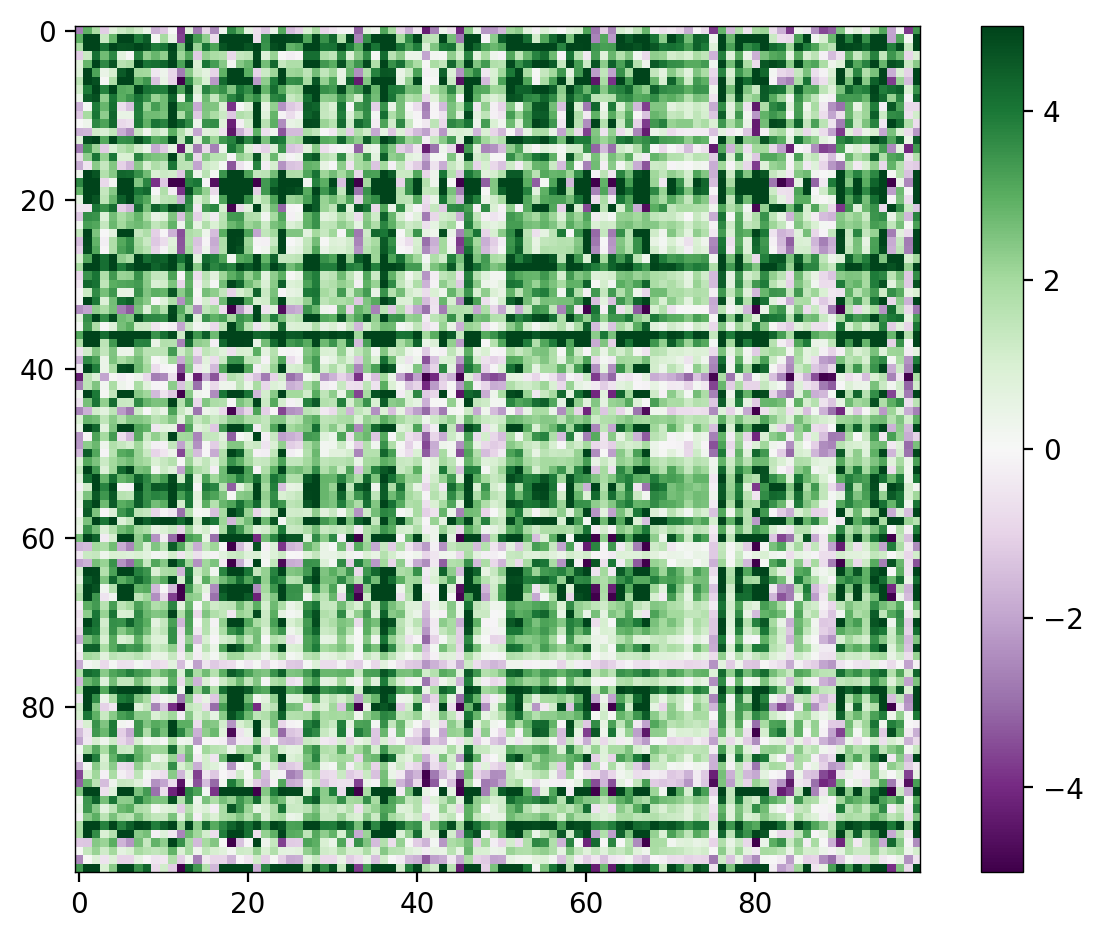

In [98]:
if mode == 'calvados':
    plt.imshow(all_cross_interactions[0:100,0:100], vmin=-15, vmax=15,cmap='PRGn',interpolation='None')
elif mode == 'mpipi':
    plt.imshow(all_cross_interactions[0:100,0:100], vmin=-5, vmax=5,cmap='PRGn',interpolation='None')
plt.colorbar()
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/arabi_effector_smol_matrix_{mode}.pdf')

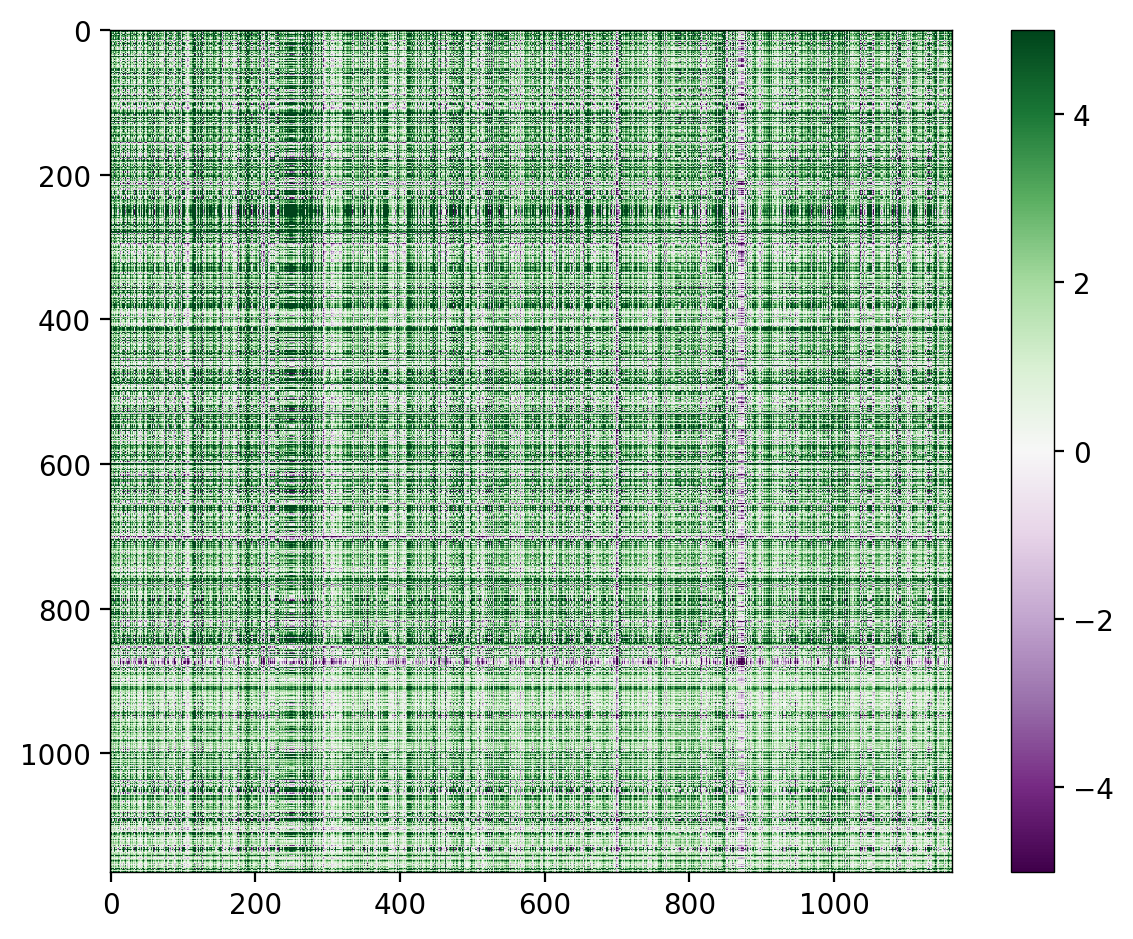

In [99]:
if mode == 'calvados':
    plt.imshow(all_cross_interactions, vmin=-15, vmax=15,cmap='PRGn',interpolation='None')
elif mode == 'mpipi':
    plt.imshow(all_cross_interactions, vmin=-5, vmax=5,cmap='PRGn',interpolation='None')

plt.colorbar()
plt.tight_layout()
#plt.savefig(f'/home/wenyuantong/Desktop/figures/arabi_effector_big_matrix_{mode}.pdf')

In [107]:
#all_cross_interactions
all_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [109]:
#all_atr_interactions
atr_df = pd.DataFrame(all_interactions, columns=['IDR1', 'IDR2','E_value'])

# Display the DataFrame
display(atr_df)

,IDR1,IDR2,E_value
0,Q9FGQ9_IDR_1_1_80,Q9FGQ9_IDR_1_1_80,-2.689291
1,Q9FGQ9_IDR_1_1_80,Q9ZV43_IDR_1_1_80,2.911596
2,Q9FGQ9_IDR_1_1_80,Q9ZV43_IDR_2_81_160,1.894774
3,Q9FGQ9_IDR_1_1_80,Q9ZV43_IDR_3_161_240,-1.111282
4,Q9FGQ9_IDR_1_1_80,Q9ZV43_IDR_4_241_320,0.728365
...,...,...,...
1354891,Q88BK3_IDR_1_73_152,Q880M5_IDR_2_81_137,7.350202
1354892,Q88BK3_IDR_1_73_152,Q884Y6_IDR_1_1_61,5.018634
1354893,Q88BK3_IDR_1_73_152,Q885Y0_IDR_1_1_32,2.484769
1354894,Q88BK3_IDR_1_73_152,Q889U1_IDR_1_111_189,0.774074


In [110]:
eff_df = pd.read_csv('/home/wenyuantong/Desktop/data/IDR_PS_noneffector_domain.tsv',  sep='\t', header=None)
display(eff_df.head())

,0,1,2
0,D3NQ26,471,491
1,Q87TZ7,117,161
2,Q87U48,1,105
3,Q87U88,1,27
4,Q87U88,277,291


In [111]:
eff_df[0] = eff_df[0].str.replace(' ', '')
substrings_to_find = eff_df[0].tolist()
display(substrings_to_find[:10])

['D3NQ26',
 'Q87TZ7',
 'Q87U48',
 'Q87U88',
 'Q87U88',
 'Q87UG8',
 'Q87VE4',
 'Q87VQ0',
 'Q87VQ0',
 'Q87WE9']

In [112]:
# Combine the substrings into a single regex pattern using '|' (OR operator)
# This pattern will match if any of the substrings are found.
search_pattern = '|'.join(substrings_to_find)

# Filter the original DataFrame
# The `case=False` argument makes the search case-insensitive
# The `na=False` argument treats NaN values as not containing the substring
sub_df_multi = atr_df[atr_df['IDR1'].str.contains(search_pattern, case=False, na=False)]

#print(f"\nSub-DataFrame containing any of the terms: {substrings_to_find} in 'item_description' column:")
display(sub_df_multi)

,IDR1,IDR2,E_value
1037124,Q87VW8_IDR_1_1_55,Q9FGQ9_IDR_1_1_80,0.405055
1037125,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_1_1_80,2.353809
1037126,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_2_81_160,3.472236
1037127,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_3_161_240,2.242515
1037128,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_4_241_320,3.577676
...,...,...,...
1354891,Q88BK3_IDR_1_73_152,Q880M5_IDR_2_81_137,7.350202
1354892,Q88BK3_IDR_1_73_152,Q884Y6_IDR_1_1_61,5.018634
1354893,Q88BK3_IDR_1_73_152,Q885Y0_IDR_1_1_32,2.484769
1354894,Q88BK3_IDR_1_73_152,Q889U1_IDR_1_111_189,0.774074


In [113]:
sub_df_not_containing = sub_df_multi[~sub_df_multi['IDR2'].str.contains(search_pattern, case=False, na=False)]

#print(f"\nSub-DataFrame containing rows that *do not* contain any of the terms in '{search_pattern}' in 'item_description' column:")
display(sub_df_not_containing)

,IDR1,IDR2,E_value
1037124,Q87VW8_IDR_1_1_55,Q9FGQ9_IDR_1_1_80,0.405055
1037125,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_1_1_80,2.353809
1037126,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_2_81_160,3.472236
1037127,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_3_161_240,2.242515
1037128,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_4_241_320,3.577676
...,...,...,...
1354618,Q88BK3_IDR_1_73_152,Q9LSU8_IDR_1_135_179,2.350546
1354619,Q88BK3_IDR_1_73_152,Q9FHZ8_IDR_1_1_48,1.895734
1354620,Q88BK3_IDR_1_73_152,F4JJ52_IDR_1_388_467,3.271745
1354621,Q88BK3_IDR_1_73_152,F4JJ52_IDR_2_468_526,4.088486


In [117]:
output_file_path = '/home/wenyuantong/Desktop/data/500_arabi_noneffector_cross.csv'
sub_df_not_containing.to_csv(output_file_path, header=True, index=False)